 ## Site Selection

This notebook will help us navigate the affected and control sites to effectibely use them in acquiring CDR data. 

The polygons for the communes have been received from the "Sonatel" company.

In this exercise the objective is to either regionalize or cluster the sites based on their homogenous properties and distinguish the group of communes based on their heterogenity. 

In general, we will look at the following indicators:



We will extract the following for the selected sites:

|Data Variable | Source | Spatial Resolution | Time| Link|
|-----------|----------------|--------|----------------|----|
|Population | From World Pop | 100 m | 2021 - 2024|https://data.humdata.org/dataset/worldpop-population-counts-2015-2030-sen|
|Land use Land Cover | iEarth | 30 m OR 10 m | 2022 or 2021-2024 | projects/sat-io/open-datasets/GLC-FCS30D/annual OR ESRI ANNUAL Product|
|Flood| UN Flood Detection Using S1 Script| Same as S1| Time of the events - used from EMDAT| Given in the reference|
|VHI | FAO | 500m | 2020 - 2024 (seasonal)|projects/UNFAO/ASIS/VHI_M'|
|Precipitation | CHIRPS | 5000 m | 2020-2024 (Seasonal)|N/A|
|Temperature | MODIS/Landsat | 1000 m or 30 m | 2020-2024 (Seasonal)|N/A
|NDVI| MODIS/Landsat | 500 m or 30 m | 2021




|Feature|	Explanation|
|------|--------|
|Population trend|	Extracts population values for 2020–2024, returns 1 if growth, 0 if decline|
|Drought/Temp/Precip|	For each year, checks if May–Oct values fall into class 1–3 for ≥35% of the polygon—if true in any year, mark 1|
|Flood presence|	Checks if any flood mask shows presence (value 1) inside a polygon|
|LULC stats|	From 2022 LULC raster, computes percentage of area that is irrigated, rainfed, built-up|
|Output CSV|	Contains all flags and LULC fractions for each adm_4 unit|

In [1]:
from helper_functions import *

### Hazard Classification

In this section we are going to classify regions based on the presence and severity of the hazard, mainly drought and flood.

### Drought Masking and Classification

Each monthly VHI raster is classified into 5 categories:

| VHI Range       | Class | Description              |
|------------------|--------|--------------------------|
| vhi < 10      | 1      | Extreme Drought          |
| 10 ≤ vhi < 20 | 2      | Moderate Drought         |
| 20 ≤ vhi < 30 | 3      | Near Normal Vegetation   |
| 30 ≤ vhi < 40 | 4      | Above Normal Vegetation  |
| vhi ≥ 40        | 5      | Very High Vegetation     |

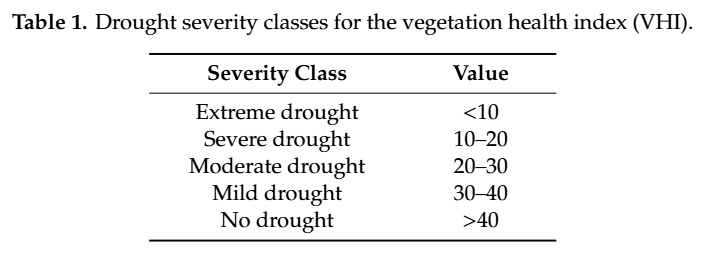
reference: http://dx.doi.org/10.3390/w12061738


A pixel is considered drought-affected if class = 1 or 2 or 3.

 - Drought Aggregation Rule
For each commune:
- If it has class 1 or 2 or 3 in a month → that month is flagged as drought
- List dry and wet season as drought based on the majority
- If majority months throughout are drought → commune is flagged as drought-prone

- Reference for VHI classification: https://www.nature.com/articles/s41597-023-02255-3/tables/1

- FAO - is the reference for choosing 0.35 or 35% as the threshold for the area under those classes. 

### Flood Masking and Classification

We had a binary band for flood masks, so it was easier to classify the regions with the flood hazard. 

| Classification     | Class | Description              |
|------------------|--------|--------------------------|
| Flood mask % >1     | 1      | Even if some of the area in the commune has flood masking = it is flagged as flooded         |
| Flood mask % <1 | 0      | No flood occurences         |

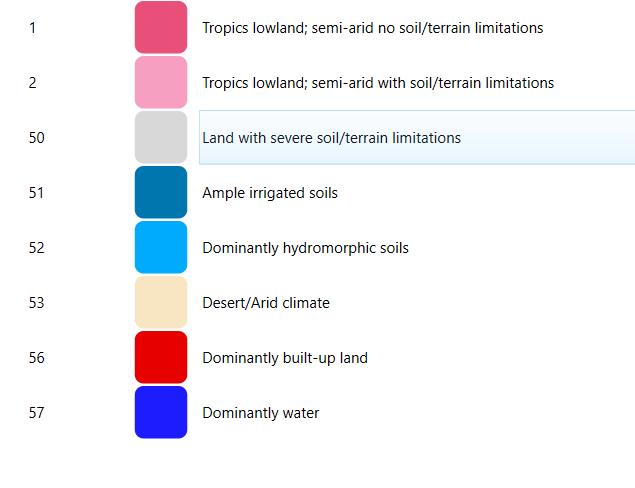

#### Combine Multiple Year VHI CSVs

In [2]:
directory = r"D:\CDR_study_areas\VHI\median_VHI"
output_file = "combine_median_VHI.csv"
# lsit items in the directory
combine_csvs(directory, output_file)


Looking for CSV files in directory: D:\CDR_study_areas\VHI\median_VHI
Found 5 CSV files


Combining CSVs: 100%|██████████| 5/5 [00:00<00:00, 68.23it/s]

Reading: combine_median_VHI.csv
  Success: 26544 rows, 8 columns
Reading: VHI_All_ADM4_2021.csv
  Success: 6636 rows, 8 columns
Reading: VHI_All_ADM4_2022.csv
  Success: 6636 rows, 8 columns
Reading: VHI_All_ADM4_2023.csv
  Success: 6636 rows, 8 columns
Reading: VHI_All_ADM4_2024.csv
  Success: 6636 rows, 8 columns

Successfully read 5 out of 5 CSV files


Combined 5 CSV files into D:\CDR_study_areas\VHI\median_VHI\combine_median_VHI.csv
Final combined file: 53088 rows, 8 columns


In [ ]:
# combine precipitation data
prep_dir = r"D:\CDR_study_areas\precipitation"
output_file = "combine_precipitation.csv"
combine_csvs(prep_dir, output_file)

In [ ]:
import zipfile
import os
tdir = r"D:\CDR_study_areas\DEM"

output_dir = os.path.join(tdir, 'DEM_tiles')
os.makedirs(output_dir, exist_ok=True)

# Loop through all files in the directory
for filename in os.listdir(tdir):
    if filename.endswith('.zip'):
        zip_path = os.path.join(tdir, filename)
        print(f'Unzipping: {filename}')
        
        # Open and extract
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)

print(f'\n✅ All files unzipped to: {output_dir}')

#### Plotting function that can be used for all the flags

#### LULC stats

For this block, we are only interested in identifying rainfed and irrigated land cover for the selected sites. We have used just the 2022 classified layer to get a rough estimation of the croplands. It is not ideal but it gives a good understanding of how much of the land is rain dependent and how much of it relies of the irrigation activities. 

#### Built-Surface

In addition to the cropland, built surface in another key indicator of mobility or of infrastructural growth in general. We are intentionally using only the residential ['res'] built surface as we are interested in the human residential areas. Unlike LULC, the bulit surface is only available in 5 year intervals, therefore, we chose the 2025 layer (2020 would not include the newer structures). 

### Operational Cells

### Cell Towers 

### LULC Mosaicking and Value Assignment

In [ ]:

output_geojson = "output/communes_with_indicators.geojson"
if not os.path.exists("output"):
    os.makedirs("output")
# change the CRS to WGS84 for GeoJSON compatibility
communes = communes.to_crs("EPSG:4326")

communes.to_file(output_geojson, driver="GeoJSON")


Processed the population stats in QGIS - because of memory issues in python - the datatype of float32 for a whole country raster to process takes a lot of memory. Instead of wasting a lot of time - I just aggregated the stats for each commune and concatenated. 

### Way Forward 

From a very estimated point of view, we have identified 32 hazard prone areas - which are a good representation of the regions we were initially interested in. In addition to those 32 regions, we have about 65 less or not affected regions [out of which], we can choose a small sample as control. 

$$
control\_sites = allowed\_sites - affected|_sites$$

### References:

- population: https://data.humdata.org/dataset/worldpop-population-counts-2015-2030-sen 
- VHI - FAO : https://www.fao.org/giews/en/
- GEE UN - Flood mask - https://www.un-spider.org/advisory-support/recommended-practices/recommended-practice-google-earth-engine-flood-mapping/step-by-step
- Night Light - Black Marble : Have not processed it yet
- Built surface - JRC Dataset : Pesaresi, Martino; Politis, Panagiotis (2023): GHS-BUILT-S R2023A - GHS built-up surface grid, derived from Sentinel2 composite and Landsat, multitemporal (1975-2030). European Commission, Joint Research Centre (JRC). PID: http://data.europa.eu/89h/9f06f36f-4b11-47ec-abb0-4f8b7b1d72ea doi:10.2905/9F06F36F-4B11-47EC-ABB0-4F8B7B1D72EA
- Precipitation - CHIRPS - Climate Hazards Center Infrared Precipitation with Stations version 3. CHIRPS3 Data Repository https://doi.org/10.15780/G2JQ0P (2025).
- Temperature - LST - Will be added soon
- LULC - Living Atlas - https://livingatlas.arcgis.com/landcover/ 

## 